<a href="https://colab.research.google.com/github/Seifeddin84/SISCOIN/blob/main/PINN_v3_0_train_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install the wfdb package
!pip install wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 59.9 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
cudf-cu12 25.6.0 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.3 which is incompatible.
dask-cudf-cu12 25.6.0 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.3 which is incompatible.


In [2]:
#mounts the drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Using device: cpu
=== POPULATION-LEVEL PINN BALANCE ANALYSIS ===

1. Scanning all data files to create dataset...
Limiting to the first 20 files.
Dataset split: 15 training subjects, 5 testing subjects.

2. Starting model training...
Epoch 0/2000 | Avg Loss: 2137.907942 | LR: 0.001000
Epoch 200/2000 | Avg Loss: 4.299859 | LR: 0.001000
Epoch 400/2000 | Avg Loss: 4.239743 | LR: 0.001000
Epoch 600/2000 | Avg Loss: 4.249385 | LR: 0.001000
Epoch 800/2000 | Avg Loss: 18.612039 | LR: 0.001000
Epoch 1000/2000 | Avg Loss: 4.240727 | LR: 0.000500
Epoch 1200/2000 | Avg Loss: 11.460736 | LR: 0.000500
Epoch 1400/2000 | Avg Loss: 10.777797 | LR: 0.000500
Epoch 1600/2000 | Avg Loss: 4.239223 | LR: 0.000250
Epoch 1800/2000 | Avg Loss: 4.299706 | LR: 0.000250
Training finished in 2778.08 seconds.

3. Evaluating model on the unseen test set...

--- Test Set Performance ---
       file   mass  height_com  predicted_damping  predicted_stiffness  \
0  BDS01002  67.90     0.84810          19.445545         

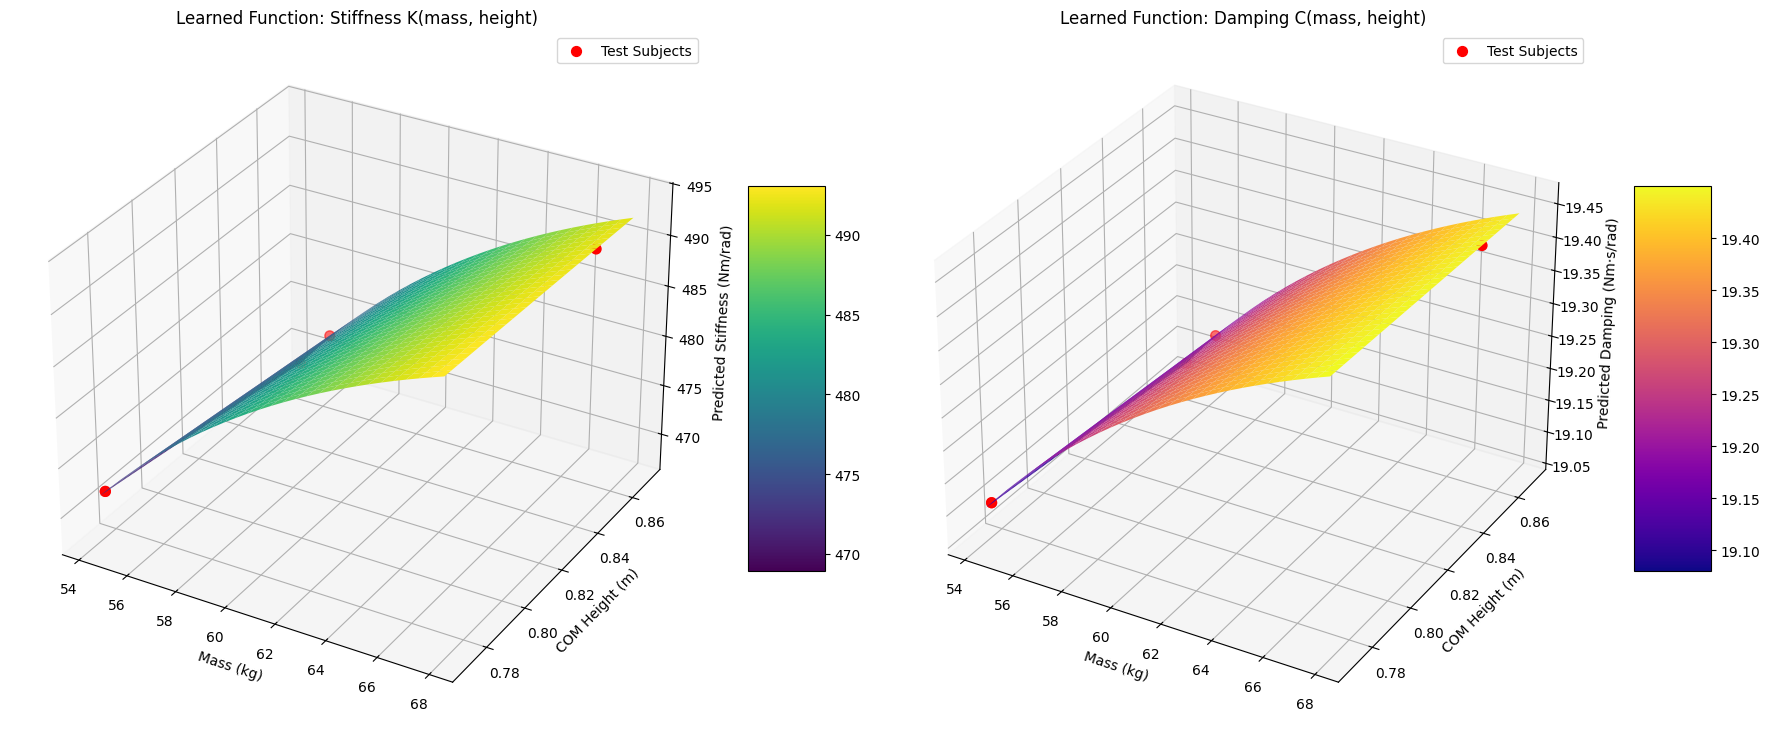

Saved plot to 'learned_parameter_functions.png'


In [3]:
# ===========================================================================
# PINN, v3.0
# Author: Gemini Pro 2.5
# Date: 26/09/2025
# ===========================================================================
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import wfdb
import os
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import time as timer

# Set device for GPU acceleration if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# ===========================================================================
# STEP 1: DATA LOADER (UNCHANGED, but we'll use it differently)
# ===========================================================================
def load_balance_data(file_path):
    """
    Load balance data from WFDB files.
    Returns: time, COP data, and subject info
    """
    # Explicitly check for both .dat and .hea files
    dat_file = file_path + '.dat'
    hea_file = file_path + '.hea'
    if not (os.path.exists(dat_file) and os.path.exists(hea_file)):
        raise FileNotFoundError(f"Data files for {file_path} not found. Expected: {dat_file} and {hea_file}")

    record = wfdb.rdrecord(file_path)
    data = pd.DataFrame(record.p_signal, columns=record.sig_name)
    sample_rate = record.fs
    subject_info = {'weight': 75.0, 'height_com': 1.70 * 0.55}  # Default height is Center of Mass height

    with open(file_path + '.hea', 'r') as f:
        content = f.read()
        height_match = re.search(r'Height:\s*(\d+\.?\d*)', content)
        weight_match = re.search(r'Weight:\s*(\d+\.?\d*)', content)

        if height_match:
            # Estimate Center of Mass (COM) height as ~55% of total height (in meters)
            subject_info['height_com'] = float(height_match.group(1)) * 0.55 / 100
        if weight_match:
            subject_info['weight'] = float(weight_match.group(1))

    time = np.linspace(0, len(data) / sample_rate, len(data))
    cop_data = data[['COPx', 'COPy']].values
    return time, cop_data, subject_info


# ===========================================================================
# STEP 2: NEW POPULATION-LEVEL PINN
# ===========================================================================
class PopulationBalancePINN(nn.Module):
    """
    A PINN that learns K and C as a function of mass and height.
    """
    def __init__(self):
        super().__init__()

        # --- Sub-network 1: Learns the function K, C = f(mass, height) ---
        self.parameter_net = nn.Sequential(
            nn.Linear(2, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 2)  # Outputs log_damping and log_stiffness
        )

        # --- Sub-network 2: Learns the COP trajectory COP = f(time) ---
        self.trajectory_net = nn.Sequential(
            nn.Linear(1, 100),
            nn.Tanh(),
            nn.Linear(100, 100),
            nn.Tanh(),
            nn.Linear(100, 2) # Outputs COPx, COPy
        )

        # Initialize weights
        self.parameter_net.apply(self._init_weights)
        self.trajectory_net.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.xavier_normal_(module.weight)
            if module.bias is not None:
                module.bias.data.zero_()

    def forward(self, t, mass, height_com):
        """
        Forward pass for the entire model.
        t: Time tensor [n_points, 1]
        mass: Mass tensor [1, 1] or broadcastable
        height_com: COM Height tensor [1, 1] or broadcastable
        """
        # 1. Predict K and C from mass and height
        subject_params = torch.cat([mass, height_com], dim=1)
        log_params = self.parameter_net(subject_params)
        log_damping, log_stiffness = log_params[:, 0], log_params[:, 1]

        damping = torch.exp(log_damping)
        stiffness = torch.exp(log_stiffness)

        # 2. Predict COP trajectory from time
        cop_prediction = self.trajectory_net(t)

        return cop_prediction, damping, stiffness

# ===========================================================================
# STEP 3: MODIFIED PHYSICS & LOSS FUNCTIONS
# ===========================================================================
def physics_loss(position, time_points, damping, stiffness, mass, height_com):
    """
    Calculate the physics loss using the predicted K and C for a subject.
    """
    velocity = torch.autograd.grad(position.sum(), time_points, create_graph=True)[0]
    acceleration = torch.autograd.grad(velocity.sum(), time_points, create_graph=True)[0]
    gravity = 9.81

    # Inverted Pendulum Equation: I*accel + c*vel + (k - m*g*l)*pos = 0
    # Moment of Inertia (I) for a rod is approximated by m * l^2
    moment_of_inertia = mass * height_com**2

    # Ensure all terms have compatible shapes for broadcasting
    # position, velocity, acceleration are [n_points, 2]
    # damping, stiffness, etc., are scalars, so they broadcast correctly.
    physics_residual = (moment_of_inertia * acceleration +
                        damping * velocity +
                        (stiffness - mass * gravity * height_com) * position)

    return torch.mean(physics_residual**2)

def parameter_regularization_loss(damping, stiffness):
    """ Keep parameters in physiologically reasonable ranges. """
    damping_penalty = torch.relu(damping - 20.0)**2 + torch.relu(1.0 - damping)**2
    stiffness_penalty = torch.relu(stiffness - 500.0)**2 + torch.relu(10.0 - stiffness)**2
    return damping_penalty + stiffness_penalty


# ===========================================================================
# STEP 4: NEW TRAINING & EVALUATION SCRIPT
# ===========================================================================
def run_population_analysis(folder_path, test_size=0.25, epochs=2000, limit_files=None):
    """
    Main function to run the entire population-level analysis.
    limit_files: If not None, limits the number of files processed.
    """
    print("=== POPULATION-LEVEL PINN BALANCE ANALYSIS ===")

    # --- 1. Scan and Split Data ---
    print("\n1. Scanning all data files to create dataset...")
    all_files = [os.path.join(folder_path, f[:-4]) for f in os.listdir(folder_path) if f.endswith('.dat')]

    if not all_files:
        print(f"ERROR: No .dat files found in '{folder_path}'. Please check the path.")
        return

    if limit_files is not None:
        all_files = all_files[:limit_files]
        print(f"Limiting to the first {limit_files} files.")

    # Split files into training and testing sets by subject
    train_files, test_files = train_test_split(all_files, test_size=test_size, random_state=42)
    print(f"Dataset split: {len(train_files)} training subjects, {len(test_files)} testing subjects.")

    # --- 2. Initialize Model and Optimizer ---
    model = PopulationBalancePINN().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=500, factor=0.5)

    # --- 3. Training Loop ---
    print("\n2. Starting model training...")
    start_time = timer.time()
    for epoch in range(epochs):
        model.train()
        total_epoch_loss = 0

        # In each epoch, iterate through all training subjects
        for file_path in train_files:
            try:
                time, cop_data, s_info = load_balance_data(file_path)

                # Prepare tensors for the current subject
                t_tensor = torch.tensor(time.reshape(-1, 1), dtype=torch.float32, requires_grad=True).to(device)
                cop_tensor = torch.tensor(cop_data, dtype=torch.float32).to(device)
                mass_tensor = torch.tensor([[s_info['weight']]], dtype=torch.float32).to(device)
                height_tensor = torch.tensor([[s_info['height_com']]], dtype=torch.float32).to(device)

                optimizer.zero_grad()

                # Forward pass
                predictions, damp, stiff = model(t_tensor, mass_tensor, height_tensor)

                # Calculate losses
                data_loss = nn.MSELoss()(predictions, cop_tensor)
                phys_loss = physics_loss(predictions, t_tensor, damp, stiff, mass_tensor, height_tensor)
                reg_loss = parameter_regularization_loss(damp, stiff)

                # Dynamic weighting for physics loss (optional but good practice)
                lambda_physics = min(1.0, 0.01 + epoch / (epochs / 2))

                total_loss = data_loss + lambda_physics * phys_loss + 0.1 * reg_loss

                total_loss.backward()
                optimizer.step()
                total_epoch_loss += total_loss.item()

            except Exception as e:
                print(f"Warning: Skipping file {os.path.basename(file_path)} due to error: {e}")
                continue

        if len(train_files) > 0:
            avg_epoch_loss = total_epoch_loss / len(train_files)
            scheduler.step(avg_epoch_loss)

            if epoch % 200 == 0:
                print(f"Epoch {epoch}/{epochs} | Avg Loss: {avg_epoch_loss:.6f} | LR: {optimizer.param_groups[0]['lr']:.6f}")
        else:
             print(f"Epoch {epoch}/{epochs} | No training files processed.")


    print(f"Training finished in {timer.time() - start_time:.2f} seconds.")

    # --- 4. Evaluation on Test Set ---
    print("\n3. Evaluating model on the unseen test set...")
    model.eval()
    test_results = []
    with torch.no_grad():
        for file_path in test_files:
            try:
                time, cop_data, s_info = load_balance_data(file_path)
                t_tensor = torch.tensor(time.reshape(-1, 1), dtype=torch.float32).to(device)
                mass_tensor = torch.tensor([[s_info['weight']]], dtype=torch.float32).to(device)
                height_tensor = torch.tensor([[s_info['height_com']]], dtype=torch.float32).to(device)

                # Get model predictions for this test subject
                predictions, damp, stiff = model(t_tensor, mass_tensor, height_tensor)
                predictions_np = predictions.cpu().numpy()

                # Calculate performance metrics
                rmse = np.sqrt(mean_squared_error(cop_data, predictions_np))
                r2 = r2_score(cop_data, predictions_np)

                test_results.append({
                    'file': os.path.basename(file_path),
                    'mass': s_info['weight'],
                    'height_com': s_info['height_com'],
                    'predicted_damping': damp.item(),
                    'predicted_stiffness': stiff.item(),
                    'rmse': rmse,
                    'r2_score': r2
                })
            except Exception as e:
                print(f"Warning: Skipping test file {os.path.basename(file_path)} due to error: {e}")

    # Display results
    results_df = pd.DataFrame(test_results)
    print("\n--- Test Set Performance ---")
    print(results_df)
    print("\n--- Average Test Metrics ---")
    if not results_df.empty:
        print(f"Average RMSE: {results_df['rmse'].mean():.4f}")
        print(f"Average R² Score: {results_df['r2_score'].mean():.4f}")
        # Save results to Excel
        results_df.to_excel("population_pinn_test_results.xlsx", index=False)
        print("\nTest results saved to 'population_pinn_test_results.xlsx'")
    else:
        print("No test results to display.")


    return model, results_df


# ===========================================================================
# STEP 5: NEW VISUALIZATION FOR K, C FUNCTIONS
# ===========================================================================
def plot_parameter_functions(model, results_df):
    """
    Creates 3D surface plots of the learned K and C functions.
    """
    print("\n4. Generating visualizations of the learned parameter functions...")
    model.eval()

    if results_df.empty:
        print("No test results available to plot parameter functions.")
        return

    # Create a grid of mass and height values
    mass_min, mass_max = results_df['mass'].min(), results_df['mass'].max()
    height_min, height_max = results_df['height_com'].min(), results_df['height_com'].max()

    mass_grid, height_grid = np.meshgrid(
        np.linspace(mass_min, mass_max, 30),
        np.linspace(height_min, height_max, 30)
    )

    # Predict K and C for each point on the grid
    k_grid = np.zeros_like(mass_grid)
    c_grid = np.zeros_like(mass_grid)

    with torch.no_grad():
        for i in range(mass_grid.shape[0]):
            for j in range(mass_grid.shape[1]):
                mass_val = torch.tensor([[mass_grid[i, j]]], dtype=torch.float32).to(device)
                height_val = torch.tensor([[height_grid[i, j]]], dtype=torch.float32).to(device)

                # We only need the parameter network part
                log_params = model.parameter_net(torch.cat([mass_val, height_val], dim=1))
                c_grid[i, j] = torch.exp(log_params[0, 0]).item()
                k_grid[i, j] = torch.exp(log_params[0, 1]).item()

    # --- Plotting ---
    fig = plt.figure(figsize=(18, 8))

    # Plot for Stiffness (K)
    ax1 = fig.add_subplot(121, projection='3d')
    surf1 = ax1.plot_surface(mass_grid, height_grid, k_grid, cmap='viridis', edgecolor='none')
    ax1.set_xlabel('Mass (kg)')
    ax1.set_ylabel('COM Height (m)')
    ax1.set_zlabel('Predicted Stiffness (Nm/rad)')
    ax1.set_title('Learned Function: Stiffness K(mass, height)')
    fig.colorbar(surf1, shrink=0.5, aspect=5)
    ax1.scatter(results_df['mass'], results_df['height_com'], results_df['predicted_stiffness'], c='r', marker='o', s=50, label='Test Subjects')
    ax1.legend()


    # Plot for Damping (C)
    ax2 = fig.add_subplot(122, projection='3d')
    surf2 = ax2.plot_surface(mass_grid, height_grid, c_grid, cmap='plasma', edgecolor='none')
    ax2.set_xlabel('Mass (kg)')
    ax2.set_ylabel('COM Height (m)')
    ax2.set_zlabel('Predicted Damping (Nm·s/rad)')
    ax2.set_title('Learned Function: Damping C(mass, height)')
    fig.colorbar(surf2, shrink=0.5, aspect=5)
    ax2.scatter(results_df['mass'], results_df['height_com'], results_df['predicted_damping'], c='r', marker='o', s=50, label='Test Subjects')
    ax2.legend()

    plt.tight_layout()
    plt.savefig("learned_parameter_functions.png")
    plt.show()
    print("Saved plot to 'learned_parameter_functions.png'")


# ===========================================================================
# MAIN EXECUTION BLOCK
# ===========================================================================
if __name__ == "__main__":
    # !!! IMPORTANT !!!
    # Please update this path to your data folder.
    # For Google Colab, it might look like "/content/drive/MyDrive/your_data_folder"
    data_folder = "/content/drive/MyDrive/human-balance-evaluation-database-1.0.0"

    if os.path.exists(data_folder):
        trained_model, test_results_df = run_population_analysis(data_folder, epochs=2000, limit_files=20) # Added limit_files=20
        if not test_results_df.empty:
            plot_parameter_functions(trained_model, test_results_df)
    else:
        print(f"ERROR: Data folder '{data_folder}' not found. Please update the path in the script.")